In [ ]:
fp = "./data/the-verdict.txt"
with open(fp, "r") as f:
    text = f.read()

## Learning Rate Warmup

In [2]:
import torch
from gpt import GPTConfig, GPTModel
from utils import create_dataloader_v1

train_ratio = 0.9
train_size = int(len(text) * train_ratio)
train_data = text[:train_size]
valid_data = text[train_size:]

gpt_cfg = GPTConfig(context_length=256)
torch.manual_seed(42)
model = GPTModel(gpt_cfg)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
model.eval()

train_dataloader = create_dataloader_v1(
    train_data,
    context_size=gpt_cfg.context_length,
    stride=gpt_cfg.context_length,
    batch_size=2,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)
valid_dataloader = create_dataloader_v1(
    valid_data,
    context_size=gpt_cfg.context_length,
    stride=gpt_cfg.context_length,
    batch_size=2,
    shuffle=False,
    drop_last=False,
    num_workers=0,
)

In [ ]:
n_epochs = 15
lr_init = 1e-4
lr_max = 1e-2
warmup_steps = 20

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
lr_incr = (lr_max - lr_init) / warmup_steps

step, tokens_seen = 0, 0
lrs = []
train_losses, valid_losses, track_tokens_seen = [], [], []
eval_freq, eval_iter = 5, 5

for epoch in range(n_epochs):
    for input_batch, target_batch in train_dataloader:
        optimizer.zero_grad()

        if step < warmup_steps:
            lr = lr_init + step * lr_incr
        else:
            lr = lr_max

        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        step += 1
        lrs.append(lr)


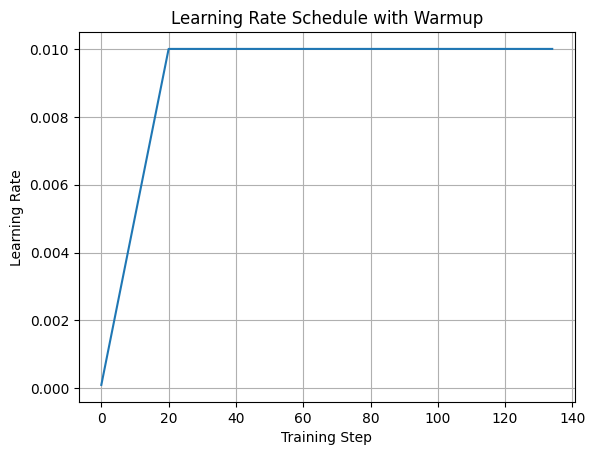

In [5]:
import matplotlib.pyplot as plt

plt.title("Learning Rate Schedule with Warmup")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
training_steps = len(train_dataloader) * n_epochs
plt.plot(range(training_steps), lrs)
plt.grid()
plt.show()

## Cosine Decay

In [ ]:
import math

lrs = []
lr_min = 0.1 * lr_init
step, tokens_seen = 0, 0
train_losses, valid_losses, track_tokens_seen = [], [], []
eval_freq, eval_iter = 5, 5
lr_incr = (lr_max - lr_init) / warmup_steps
total_training_steps = len(train_dataloader) * n_epochs

for epoch in range(n_epochs):
    for input_batch, target_batch in train_dataloader:
        optimizer.zero_grad()

        if step < warmup_steps:
            lr = lr_init + step * lr_incr
        else:
            progress = (step - warmup_steps) / (total_training_steps - warmup_steps)
            lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * progress))

        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        step += 1
        lrs.append(lr)

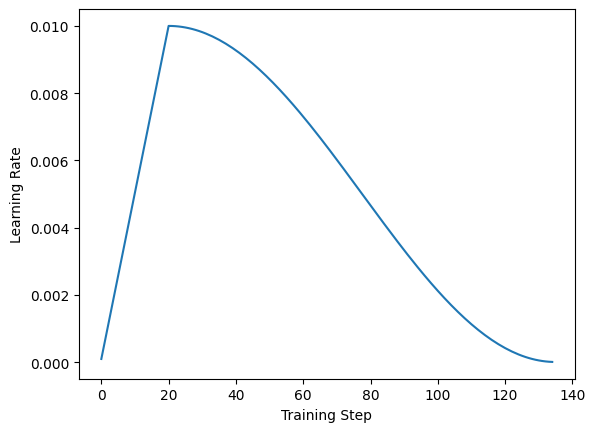

In [ ]:
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.plot(range(total_training_steps), lrs)
plt.show()

## Gradient Clipping

In [8]:
from train import calc_loss_batch

torch.manual_seed(42)
loss = calc_loss_batch(input_batch, target_batch, model)
loss.backward()

In [12]:
def find_highest_gradient(model):
    max_grad = 0.0
    for param in model.parameters():
        if param.grad is not None:
            param_max_grad = param.grad.abs().max()
            if param_max_grad > max_grad:
                max_grad = param_max_grad
    return max_grad

print(find_highest_gradient(model))

tensor(0.0478, device='mps:0')


In [13]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(find_highest_gradient(model))

tensor(0.0216, device='mps:0')


## modified training function

In [ ]:
import tiktoken
from train import train_model_2

n_epochs = 15
warmup_steps = 20
tokenizer = tiktoken.get_encoding("gpt2")
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
start_context = "Every effort moves you"

torch.manual_seed(42)
train_losses, valid_losses, tokens_seen, lrs = train_model_2(
    model,
    train_dataloader,
    valid_dataloader,
    optimizer,
    num_epochs=n_epochs,
    eval_freq=5,
    eval_iter=1,
    tokenizer=tokenizer,
    start_context=start_context,
    warmup_steps=warmup_steps,
    lr_init=1e-5,
    lr_min=1e-5,
)

Epoch 1/15, Step 1, Train Loss: 10.9351, Valid Loss: 11.0080
Epoch 1/15, Step 5, Train Loss: 9.4669, Valid Loss: 9.5887
Every effort moves you,,,,,,,,,,,, the,,,,,, the,,,,, the,,,,,,,,,,,,,,,,,,,,,,,,
Epoch 2/15, Step 10, Train Loss: 7.8473, Valid Loss: 8.1522
Epoch 2/15, Step 15, Train Loss: 6.5439, Valid Loss: 6.7492
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Epoch 3/15, Step 20, Train Loss: 5.9537, Valid Loss: 6.6993
Epoch 3/15, Step 25, Train Loss: 5.8001, Valid Loss: 6.8456
Every effort moves you I I I I I I I I I I, and I, and I, and, and, and.     ", and, and, and, and, and, and, and, and, and, and,
Epoch 4/15, Step 30, Train Loss: 5.3603, Valid Loss: 6.8595
Epoch 4/15, Step 35, Train Loss: 4.7212, Valid Loss: 6.6620
Every effort moves you know.                                                
Epoch 5/15, Step 40, Train Loss: 3.9228, Valid Loss: 6.4915
Epoch 5/15, Step 45, Train Loss: 3.2808, Valid Loss: 6.4304
Every effort moves you know throughia'